In [1]:
import torch
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import BlipProcessor, BlipForQuestionAnswering
from peft import LoraConfig, get_peft_model
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from peft import LoraConfig,get_peft_model

In [3]:
dev='cuda' if torch.cuda.is_available() else 'cpu'

In [4]:
pro=BlipProcessor.from_pretrained('Salesforce/blip-vqa-base')
mod=BlipForQuestionAnswering.from_pretrained('Salesforce/blip-vqa-base')

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForQuestionAnswering LOAD REPORT from: Salesforce/blip-vqa-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 
text_encoder.embeddings.position_ids      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
mod.to(dev)

BlipForQuestionAnswering(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((768,), eps=1e-05, e

In [6]:
def lor(model, exp):
    layers = [3, 6, 9, 11] 
    r, alpha = 16, 32 
    tar_list = []
    if exp == 'lang':
        for i in layers:
            tar_list.append(f"text_encoder.encoder.layer.{i}.attention.self.query")
            tar_list.append(f"text_encoder.encoder.layer.{i}.attention.self.value")
    elif exp == 'img':
        for i in layers:
            tar_list.append(f"vision_model.encoder.layers.{i}.self_attn.qkv")
    elif exp == 'cross':
        for i in layers:
            # These are the critical grounding layers
            tar_list.append(f"text_encoder.encoder.layer.{i}.crossattention.self.query")
            tar_list.append(f"text_encoder.encoder.layer.{i}.crossattention.self.value")
    cfg = LoraConfig(r=r, lora_alpha=alpha, target_modules=tar_list, lora_dropout=0.05)
    return get_peft_model(model, cfg)

In [7]:
data=load_dataset('lmms-lab/VQAv2',split='validation',streaming=True)

README.md:   0%|          | 0.00/962 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/68 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/36 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/143 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/68 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/36 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/143 [00:00<?, ?it/s]

In [8]:
next(iter(data))

{'question_type': 'none of the above',
 'multiple_choice_answer': 'down',
 'answers': [{'answer': 'down', 'answer_confidence': 'yes', 'answer_id': 1},
  {'answer': 'down', 'answer_confidence': 'yes', 'answer_id': 2},
  {'answer': 'at table', 'answer_confidence': 'yes', 'answer_id': 3},
  {'answer': 'skateboard', 'answer_confidence': 'yes', 'answer_id': 4},
  {'answer': 'down', 'answer_confidence': 'yes', 'answer_id': 5},
  {'answer': 'table', 'answer_confidence': 'yes', 'answer_id': 6},
  {'answer': 'down', 'answer_confidence': 'yes', 'answer_id': 7},
  {'answer': 'down', 'answer_confidence': 'yes', 'answer_id': 8},
  {'answer': 'down', 'answer_confidence': 'yes', 'answer_id': 9},
  {'answer': 'down', 'answer_confidence': 'yes', 'answer_id': 10}],
 'image_id': 262148,
 'answer_type': 'other',
 'question_id': 262148000,
 'question': 'Where is he looking?',
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x512>}

In [9]:
data=data.shuffle(buffer_size=1000)

In [10]:
from collections import Counter

In [11]:
def mehnat(exp, stp=1500):
    model = BlipForQuestionAnswering.from_pretrained('Salesforce/blip-vqa-base')
    model = lor(model, exp)
    model.to(dev)
    optim = torch.optim.AdamW(model.parameters(), lr=1e-4)
    scl = torch.amp.GradScaler('cuda')
    attn_maps = []
    captured_weights = []
    def hook_fn(module, input, output):
        if isinstance(output, tuple) and len(output) > 1:
            captured_weights.append(output[1].detach().cpu())
    hook_target = model.text_encoder.encoder.layer[11].crossattention.self
    handle = hook_target.register_forward_hook(hook_fn)
    it = iter(data)
    for st in range(stp):
        try: ex = next(it)
        except: break
        img = ex['image'].convert('RGB')
        que = ex['question']
        ans = Counter([e['answer'] for e in ex['answers']]).most_common(1)[0][0]    
        inputs = pro(images=img, text=que, return_tensors='pt').to(dev)
        labels = pro.tokenizer(ans, return_tensors='pt').input_ids.to(dev)   
        model.train()
        optim.zero_grad()
        with torch.amp.autocast('cuda'):
            out = model(**inputs, labels=labels, output_attentions=True)
            l = out.loss     
        scl.scale(l).backward()
        scl.step(optim)
        scl.update()
        if st % 20 == 0 and captured_weights:
            latest_attn = captured_weights[-1]
            attn_maps.append({'attn': latest_attn, 'image': img, 'que': que, 'ans': ans})
            captured_weights.clear()
        if st % 150 == 0: print(f'{exp} | step {st} | loss {l.item():.4f}')
    handle.remove()
    return {"loss": 0, "attn": attn_maps, "model": model}

In [12]:
exp=['lang','img','cross']
res={}
mods = {}
attns = {}

In [13]:
for x in exp:
    out = mehnat(x) # Reduced steps for quick testing
    res[x] = out["loss"]
    mods[x] = out["model"]
    attns[x] = out["attn"]

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForQuestionAnswering LOAD REPORT from: Salesforce/blip-vqa-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 
text_encoder.embeddings.position_ids      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


lang | step 0 | loss 0.1079
lang | step 150 | loss 2.1509
lang | step 300 | loss 0.1112
lang | step 450 | loss 0.4473
lang | step 600 | loss 0.1901
lang | step 750 | loss 0.3132
lang | step 900 | loss 0.1043
lang | step 1050 | loss 1.2574
lang | step 1200 | loss 0.6689
lang | step 1350 | loss 0.1064


Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForQuestionAnswering LOAD REPORT from: Salesforce/blip-vqa-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 
text_encoder.embeddings.position_ids      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


img | step 0 | loss 0.1079
img | step 150 | loss 2.1433
img | step 300 | loss 0.1122
img | step 450 | loss 0.4434
img | step 600 | loss 0.2047
img | step 750 | loss 0.2659
img | step 900 | loss 0.1125
img | step 1050 | loss 1.2212
img | step 1200 | loss 0.9387
img | step 1350 | loss 0.1241


Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForQuestionAnswering LOAD REPORT from: Salesforce/blip-vqa-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 
text_encoder.embeddings.position_ids      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


cross | step 0 | loss 0.1079
cross | step 150 | loss 2.1631
cross | step 300 | loss 0.1129
cross | step 450 | loss 0.4510
cross | step 600 | loss 0.2037
cross | step 750 | loss 0.3013
cross | step 900 | loss 0.1089
cross | step 1050 | loss 1.2688
cross | step 1200 | loss 0.4975
cross | step 1350 | loss 0.1166


In [14]:
def viz_attn(entry, target_word=None):
    img = entry["image"]
    que = entry["que"]
    enc = pro.tokenizer(que)
    all_tokens = pro.tokenizer.convert_ids_to_tokens(enc['input_ids'])
    attn = entry["attn"].mean(1)[0]
    if target_word:
        try:
            token_idx = [i for i, t in enumerate(all_tokens) if target_word.lower() in t.lower()][0]
        except:
            print(f"Word '{target_word}' not found, defaulting to max focus.")
            token_idx = torch.argmax(attn[1:-1, 1:].max(dim=1)[0]).item() + 1
    else:
        token_focus = attn[1:-1, 1:].max(dim=1)[0] 
        token_idx = torch.argmax(token_focus).item() + 1
    word_visualized = all_tokens[token_idx]
    grid_data = attn[token_idx, 1:].numpy()
    grid = grid_data.reshape(24, 24)
    grid = (grid - grid.min()) / (grid.max() - grid.min() + 1e-8)
    plt.figure(figsize=(8, 8))
    plt.imshow(img.resize((384, 384)))
    plt.imshow(grid, cmap='jet', alpha=0.5, extent=(0, 384, 384, 0), interpolation='bilinear')
    plt.title(f"Q: {que}\nFocus Word: '{word_visualized}' | Ans: {entry['ans']}")
    plt.axis('off')
    plt.show()

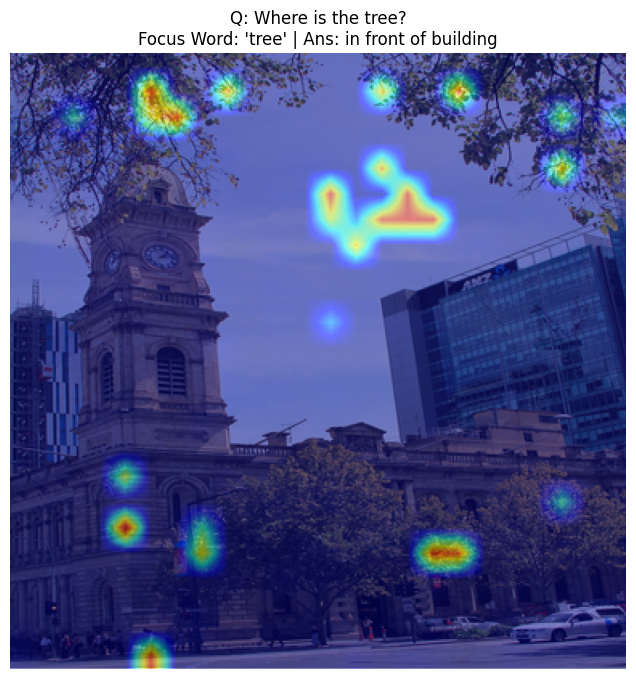

In [15]:
viz_attn(out['attn'][-1])

Word 'animals' not found, defaulting to max focus.


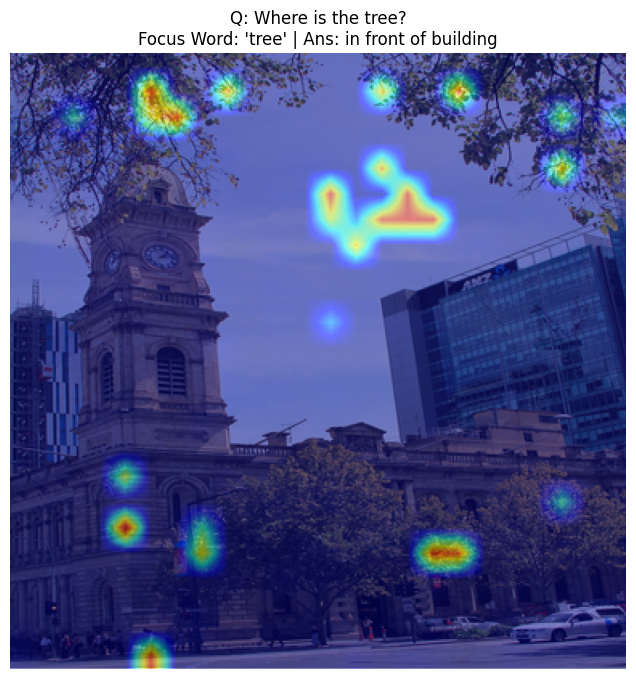

In [16]:
viz_attn(out['attn'][-1], target_word="animals")